# creating a dataset with augmented data using VAE-TIMEGAN

In [2]:
import numpy as np
import pandas as pd

In [3]:
fake_df = pd.read_csv("cleaned_data_VAETIMEGAN.csv")
real_df = pd.read_csv("final_data.csv")

In [4]:
fake_df

,CPI,TB3MS,M1,M2,AUD_USD,CAD_USD,NZD_USD,ZAR_USD,WTI_price
0,-0.005484,-0.073454,0.013188,0.008006,0.012299,-0.002406,-0.006743,-0.023616,-0.203766
1,-0.003673,-0.079281,0.011769,0.009704,0.020833,-0.009353,0.060724,0.005213,0.018075
2,0.002756,0.014742,0.017015,0.010501,0.006006,-0.008792,0.009556,0.067115,0.180503
3,0.003663,0.009709,0.013104,0.007785,-0.054147,0.010266,-0.037406,0.144931,-0.135577
4,0.000914,-0.063144,0.014577,0.008258,-0.090823,-0.006553,-0.026149,0.010176,-0.147348
...,...,...,...,...,...,...,...,...,...
330,0.000377,-0.693147,0.013443,0.005613,0.029055,-0.006249,0.030671,-0.010897,-0.002631
331,0.000535,0.916291,0.017471,0.011379,0.022900,0.001977,0.022073,-0.006414,-0.055616
332,0.001843,0.336472,0.003021,0.000846,-0.020622,0.011857,-0.010294,0.030155,-0.068751
333,0.002641,0.000000,0.013109,0.005849,-0.037567,0.014463,-0.004297,0.016274,0.039381


In [5]:
real_df

,Date,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret,CPI,TB3MS,M1,M2,wti_ret
0,1986-02-01,-0.001030,-0.001919,0.029004,-0.122803,-0.005468,-0.01,0.003518,0.000302,-0.394190
1,1986-03-01,0.012299,-0.002406,-0.006743,-0.023616,-0.003663,-0.50,0.007092,0.003699,-0.203766
2,1986-04-01,0.020833,-0.009353,0.060724,0.005213,0.001811,-0.50,-0.001419,0.001697,0.018075
3,1986-05-01,0.006006,-0.008792,0.009556,0.067115,0.006429,0.09,0.005246,0.000797,0.180503
4,1986-06-01,-0.054147,0.010266,-0.037406,0.144931,0.000907,0.06,-0.003911,-0.002716,-0.135577
...,...,...,...,...,...,...,...,...,...,...
475,2025-09-01,0.015662,0.002685,-0.003248,-0.015405,-0.000530,-0.20,0.002021,0.001084,-0.013973
476,2025-10-01,-0.007722,0.011027,-0.020480,-0.008821,-0.000530,-0.10,0.000990,-0.000535,-0.049189
477,2025-11-01,-0.006912,0.004884,-0.019770,-0.002464,-0.000530,-0.04,-0.003364,-0.002283,-0.013725
478,2025-12-01,0.021442,-0.018762,0.023579,-0.023312,-0.000530,-0.19,0.003410,0.002887,-0.035418


In [14]:
import pandas as pd

df1 = fake_df.copy()
df2 = real_df.copy()

df2["Date"] = pd.to_datetime(df2["Date"])
first_date_df2 = df2["Date"].iloc[0]

df1["Date"] = pd.date_range(
    end=first_date_df2 - pd.DateOffset(months=1),
    periods=len(df1),
    freq="MS"
)

# rename
df1 = df1.rename(columns={
    "AUD_USD": "AUD_USD_ret",
    "CAD_USD": "CAD_USD_ret",
    "NZD_USD": "NZD_USD_ret",
    "ZAR_USD": "ZAR_USD_ret",
    "WTI_price": "wti_ret"
})

# align
df1 = df1[df2.columns]
df_final = pd.concat([df1, df2], axis=0, ignore_index=True)


df_final = df_final.sort_values("Date").reset_index(drop=True)

In [15]:
df_final

# export to csv
#df_final.to_csv("final_data_with_VAETIMEGAN.csv", index=False)

,Date,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret,CPI,TB3MS,M1,M2,wti_ret
0,1958-03-01,0.012299,-0.002406,-0.006743,-0.023616,-0.005484,-0.073454,0.013188,0.008006,-0.203766
1,1958-04-01,0.020833,-0.009353,0.060724,0.005213,-0.003673,-0.079281,0.011769,0.009704,0.018075
2,1958-05-01,0.006006,-0.008792,0.009556,0.067115,0.002756,0.014742,0.017015,0.010501,0.180503
3,1958-06-01,-0.054147,0.010266,-0.037406,0.144931,0.003663,0.009709,0.013104,0.007785,-0.135577
4,1958-07-01,-0.090823,-0.006553,-0.026149,0.010176,0.000914,-0.063144,0.014577,0.008258,-0.147348
...,...,...,...,...,...,...,...,...,...,...
810,2025-09-01,0.015662,0.002685,-0.003248,-0.015405,-0.000530,-0.200000,0.002021,0.001084,-0.013973
811,2025-10-01,-0.007722,0.011027,-0.020480,-0.008821,-0.000530,-0.100000,0.000990,-0.000535,-0.049189
812,2025-11-01,-0.006912,0.004884,-0.019770,-0.002464,-0.000530,-0.040000,-0.003364,-0.002283,-0.013725
813,2025-12-01,0.021442,-0.018762,0.023579,-0.023312,-0.000530,-0.190000,0.003410,0.002887,-0.035418


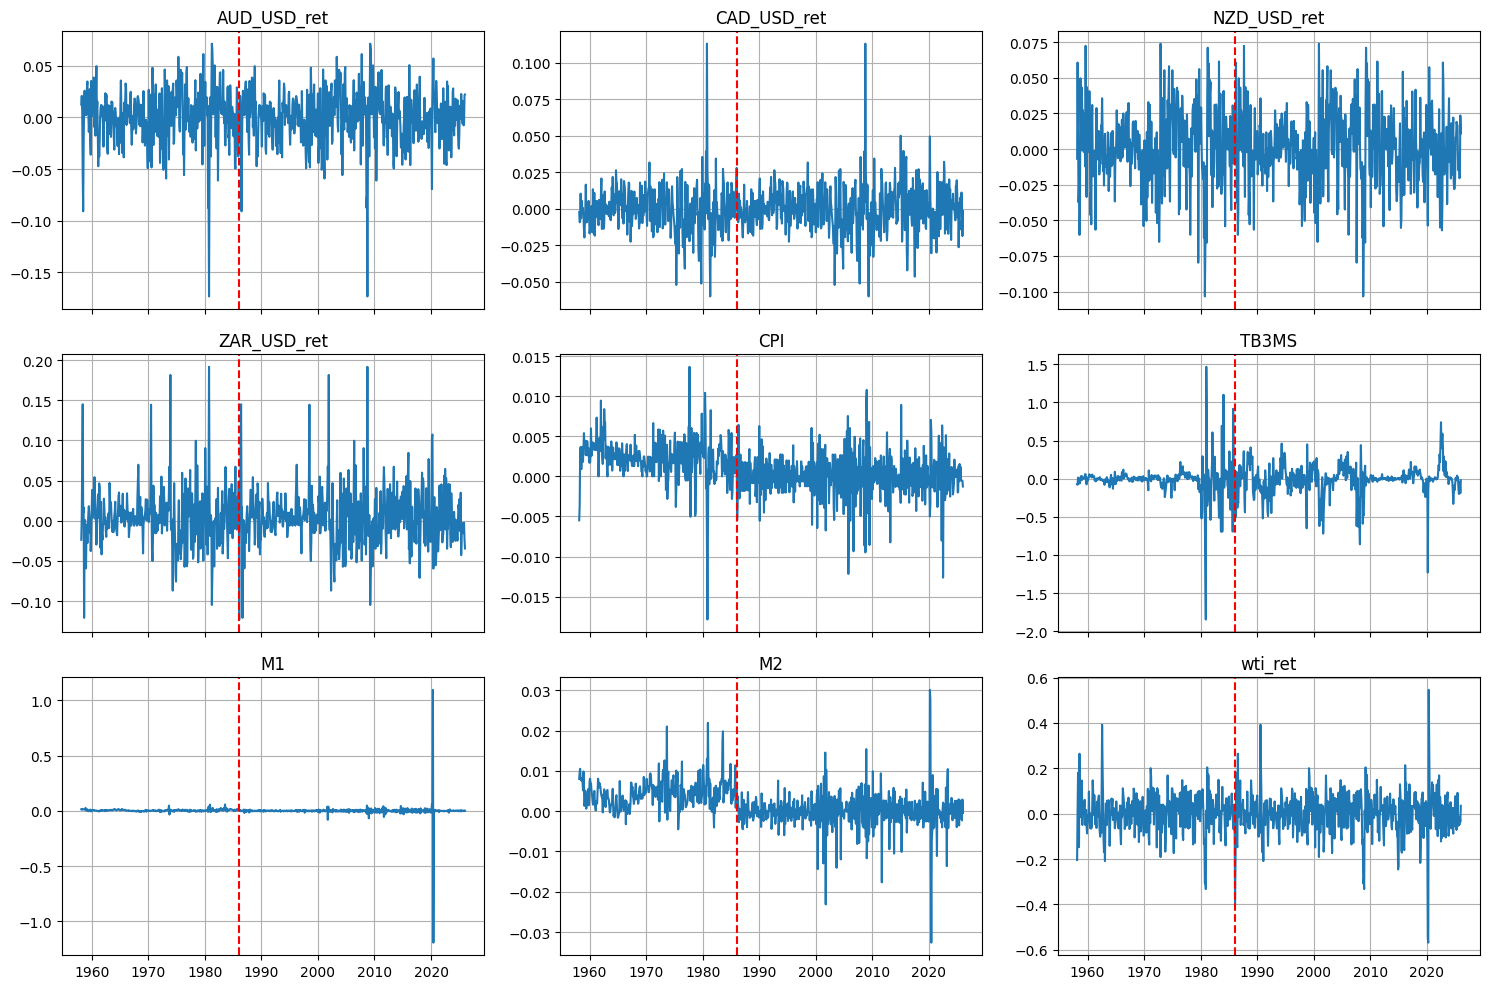

In [17]:
import matplotlib.pyplot as plt

# make sure Date is datetime and sorted
df_final["Date"] = pd.to_datetime(df_final["Date"])
df_final = df_final.sort_values("Date")

# columns to plot (exclude Date)
cols = [c for c in df_final.columns if c != "Date"]

# vertical reference line
cutoff_date = pd.to_datetime("1986-02-01")

# create 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)

axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    
    ax.plot(df_final["Date"], df_final[col])
    ax.axvline(cutoff_date, linestyle="--", color = 'red')  # vertical dashed line to indicate anything before is synthetic
    
    ax.set_title(col)
    ax.grid(True)

# remove extra axes if any
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()